# Evaluation 02: Pattern/Texture Analysis

## Research Question
**Does it ignore patterns or textures?**

### Hypothesis
If the model ignores patterns, recommendations will not preserve pattern type (striped, printed, solid), indicating the embedding may focus on other attributes.

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from evaluation_utils import (
    load_vectors_and_metadata,
    initialize_recommender,
    extract_pattern_type,
    compute_diversity_score,
    save_plot,
    save_metrics
)
from similarity import SimilarityMatcher

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

## 2. Load Data

In [2]:
vectors, metadata, product_ids = load_vectors_and_metadata()

# Extract pattern types
metadata['pattern_type'] = metadata['productDisplayName'].apply(extract_pattern_type)
print(f"Pattern type distribution:")
print(metadata['pattern_type'].value_counts())

Loading vectors and metadata...
Loading vectors from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_features_pca512.npy
Loaded 41802 vectors of dimension 512
Loading metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
Loaded 41802 metadata records
Pattern type distribution:
pattern_type
Unknown      34832
Printed       3701
Striped       1842
Solid         1367
Patterned       60
Name: count, dtype: int64


## 3. Initialize Recommender

In [3]:
similarity_matcher = SimilarityMatcher()
print("✓ Similarity matcher initialized")

Loading existing FAISS index...
✓ Loaded FAISS index with 41802 products
Using FAISS vector database
Loading product metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
FAISS index contains 41802 products
✓ Similarity matcher initialized


## 4. Generate Test Cases by Pattern Type

In [4]:
# Group by pattern type
pattern_groups = {}
for pattern in ['Solid', 'Striped', 'Printed', 'Patterned']:
    pattern_items = metadata[metadata['pattern_type'] == pattern]
    if len(pattern_items) >= 10:
        pattern_groups[pattern] = pattern_items.sample(n=10, random_state=42).index.tolist()

print(f"Generated test cases for {len(pattern_groups)} pattern types")

Generated test cases for 4 pattern types


## 5. Get Recommendations

In [5]:
results = {}
top_k = 20

for pattern, indices in pattern_groups.items():
    print(f"\nProcessing {pattern}...")
    test_features = vectors[indices]
    avg_features = test_features.mean(axis=0)
    
    recommendations = similarity_matcher.find_similar_products(
        avg_features.reshape(1, -1),
        top_k=top_k,
        min_similarity=0.0
    )
    
    if len(recommendations) > 0:
        # Add pattern type to recommendations
        # The recommendations DataFrame already has 'id', so we merge on that
        if 'pattern_type' not in recommendations.columns:
            # Merge pattern_type from metadata
            recs_with_pattern = recommendations.merge(
                metadata[['id', 'pattern_type']], 
                on='id', 
                how='left'
            )
        else:
            recs_with_pattern = recommendations.copy()
        
        results[pattern] = recs_with_pattern
        print(f"  Got {len(recs_with_pattern)} recommendations")
    else:
        print(f"  No recommendations found")


Processing Solid...
  Got 20 recommendations

Processing Striped...
  Got 20 recommendations

Processing Printed...
  Got 20 recommendations

Processing Patterned...
  Got 20 recommendations


## 6. Analyze Pattern Preservation

In [6]:
pattern_metrics = []

for pattern, recs in results.items():
    if len(recs) == 0:
        continue
    
    # Check if pattern_type column exists and handle NaN values
    if 'pattern_type' not in recs.columns:
        print(f"Warning: pattern_type not found in recommendations for {pattern}")
        continue
    
    # Fill NaN values with 'Unknown'
    recs_pattern = recs['pattern_type'].fillna('Unknown')
    
    # Pattern preservation rate
    pattern_match_rate = (recs_pattern == pattern).sum() / len(recs)
    
    # Pattern diversity
    pattern_diversity = compute_diversity_score(recs_pattern)
    
    # Average similarity
    avg_similarity = recs['similarity_score'].mean()
    
    pattern_metrics.append({
        'pattern_type': pattern,
        'preservation_rate': pattern_match_rate,
        'pattern_diversity': pattern_diversity,
        'avg_similarity': avg_similarity,
        'n_recommendations': len(recs)
    })

if len(pattern_metrics) > 0:
    metrics_df = pd.DataFrame(pattern_metrics)
    print("Pattern Analysis Metrics:")
    print(metrics_df)
else:
    print("No metrics computed - check if recommendations were generated successfully")
    metrics_df = pd.DataFrame()

Pattern Analysis Metrics:
  pattern_type  preservation_rate  pattern_diversity  avg_similarity  \
0        Solid               0.25               0.15        0.578166   
1      Striped               0.90               0.10        0.827935   
2      Printed               0.50               0.15        0.652836   
3    Patterned               0.10               0.10        0.662286   

   n_recommendations  
0                 20  
1                 20  
2                 20  
3                 20  


## 7. Visualizations

### Visualization: Pattern Type Transition Matrix

**What this graph shows:**
- A heatmap matrix showing which pattern types are recommended for each query pattern type
- Rows represent query pattern types (Solid, Striped, Printed, Patterned)
- Columns represent recommended pattern types
- Color intensity shows the proportion of recommendations (darker = more frequent)
- Diagonal shows same-pattern matches (query pattern → same pattern)

**Key Insights:**
- **Pattern preservation**: Strong diagonal = model preserves patterns; scattered pattern = ignores patterns
- **Pattern relationships**: Which patterns are recommended together (e.g., Striped → Printed)
- **Model behavior**: Whether the model distinguishes between different pattern types
- **Bias detection**: If all patterns recommend the same type, the model may be ignoring pattern information
- **Cross-pattern recommendations**: Off-diagonal patterns show which pattern combinations the model finds similar


### Visualization: Pattern Preservation Rate

**What this graph shows:**
- A bar chart displaying the percentage of recommendations that match the query pattern type
- Shows preservation rate for each pattern type (Solid, Striped, Printed, Patterned)
- Includes a red dashed line at 50% threshold for reference

**Key Insights:**
- **Pattern sensitivity**: High preservation rates (>70%) indicate the model recognizes and preserves patterns
- **Pattern-specific performance**: Some patterns may be better preserved than others
- **Model capability**: Low rates (<50%) suggest the model may be ignoring pattern/texture information
- **Recommendation quality**: Higher preservation = more consistent pattern matching in recommendations
- **Threshold analysis**: How many pattern types exceed the 50% threshold indicates overall pattern awareness


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/pattern_transition_matrix.png


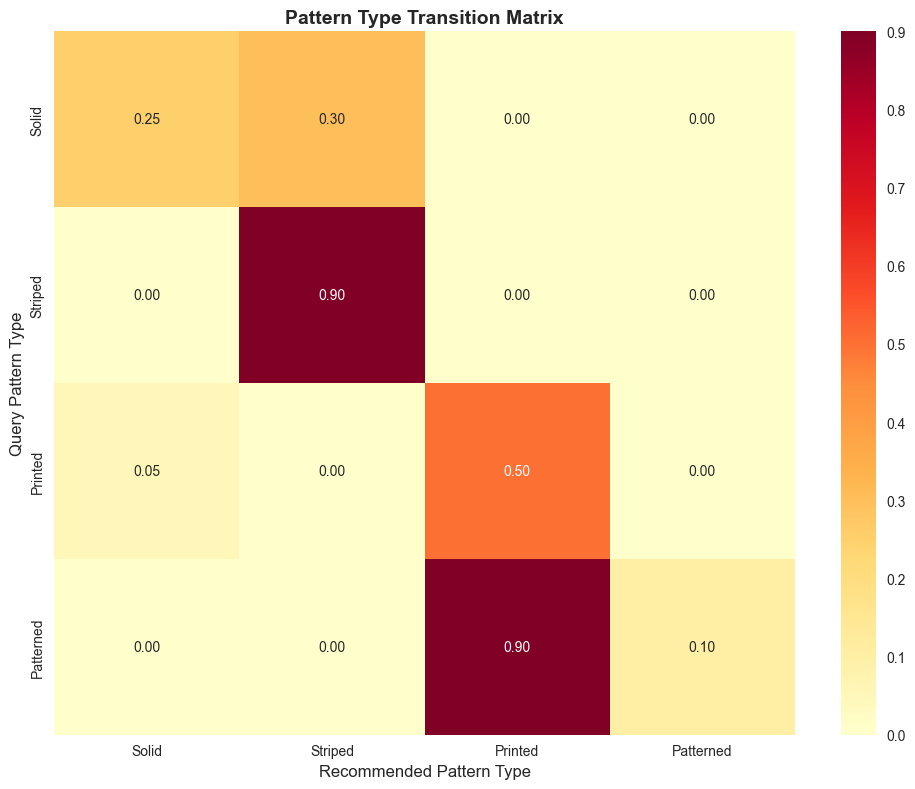

In [7]:
# Pattern transition matrix
pattern_list = ['Solid', 'Striped', 'Printed', 'Patterned']
heatmap_data = np.zeros((len(pattern_list), len(pattern_list)))

for i, query_pattern in enumerate(pattern_list):
    if query_pattern in results:
        recs = results[query_pattern]
        if 'pattern_type' in recs.columns:
            # Fill NaN and get value counts
            pattern_counts = recs['pattern_type'].fillna('Unknown').value_counts()
            
            for j, rec_pattern in enumerate(pattern_list):
                if rec_pattern in pattern_counts.index:
                    heatmap_data[i, j] = pattern_counts[rec_pattern] / len(recs)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, 
            xticklabels=pattern_list, 
            yticklabels=pattern_list,
            annot=True, 
            fmt='.2f',
            cmap='YlOrRd')
ax.set_xlabel('Recommended Pattern Type', fontsize=12)
ax.set_ylabel('Query Pattern Type', fontsize=12)
ax.set_title('Pattern Type Transition Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
save_plot(fig, 'pattern_transition_matrix.png')
plt.show()

### Visualization: Embedding Space by Pattern Type

**What this graph shows:**
- A 3D scatter plot showing how products cluster in the embedding space based on pattern type
- Each point represents a product, colored by its pattern type (Solid, Striped, Printed, Patterned, Unknown)
- The 3D space is created by reducing the 512-dimensional embeddings to 3 dimensions using PCA

**Key Insights:**
- **Pattern clustering**: Do products with the same pattern type cluster together in the embedding space?
- **Pattern separation**: Clear separation between pattern types = good pattern recognition; overlapping = poor distinction
- **Embedding quality**: Well-separated clusters indicate the model captures pattern/texture information
- **Unknown pattern handling**: How "Unknown" patterns are distributed reveals model behavior on unlabeled items
- **Visual relationships**: Can we see which pattern types are visually similar based on their proximity in space?


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/pattern_preservation_rate.png


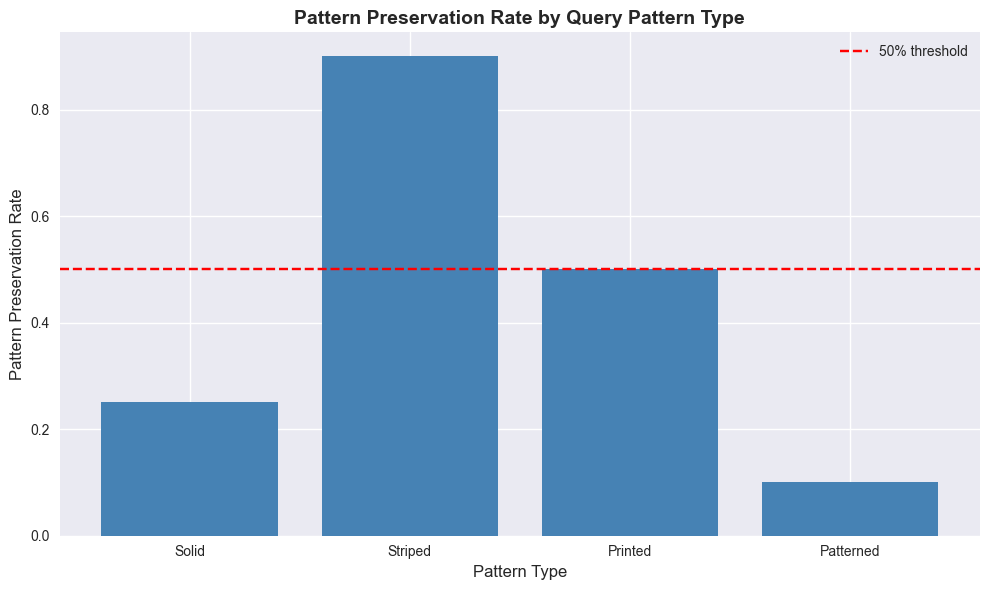

In [8]:
# Pattern preservation rate
if len(metrics_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(metrics_df['pattern_type'], metrics_df['preservation_rate'], color='steelblue')
    ax.set_ylabel('Pattern Preservation Rate', fontsize=12)
    ax.set_xlabel('Pattern Type', fontsize=12)
    ax.set_title('Pattern Preservation Rate by Query Pattern Type', fontsize=14, fontweight='bold')
    ax.axhline(y=0.5, color='red', linestyle='--', label='50% threshold')
    ax.legend()
    plt.tight_layout()
    save_plot(fig, 'pattern_preservation_rate.png')
    plt.show()
else:
    print("No data to plot - metrics_df is empty")

## 8. Embedding Space Visualization by Pattern

/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aasrithagopalam/Documents/Aasr

Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/pattern_embedding_space.png


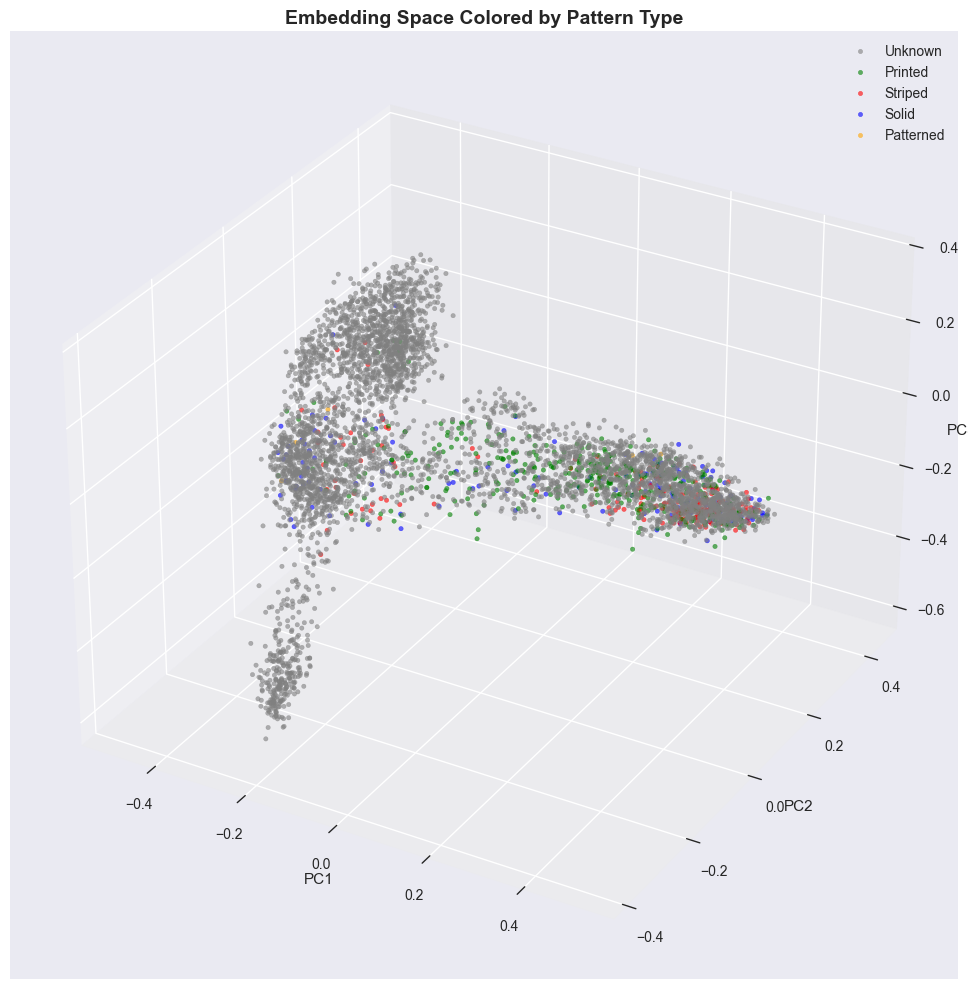

In [9]:
# Sample for visualization
sample_size = 5000
if len(vectors) > sample_size:
    indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[indices]
    sample_metadata = metadata.iloc[indices]
else:
    sample_vectors = vectors
    sample_metadata = metadata

# Reduce to 3D
from sklearn.decomposition import PCA
pca = PCA(n_components=3, random_state=42)
vectors_3d = pca.fit_transform(sample_vectors)

# Plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

pattern_types = sample_metadata['pattern_type'].unique()
colors_map = {'Solid': 'blue', 'Striped': 'red', 'Printed': 'green', 'Patterned': 'orange', 'Unknown': 'gray'}

for pattern in pattern_types:
    mask = sample_metadata['pattern_type'] == pattern
    if mask.sum() > 0:
        ax.scatter(vectors_3d[mask, 0], vectors_3d[mask, 1], vectors_3d[mask, 2],
                  c=colors_map.get(pattern, 'gray'), label=pattern, alpha=0.6, s=10)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Embedding Space Colored by Pattern Type', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
save_plot(fig, 'pattern_embedding_space.png')
plt.show()

## 9. Summary and Conclusion

In [10]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

if len(metrics_df) > 0:
    print(f"\nOverall Pattern Preservation Rate: {metrics_df['preservation_rate'].mean():.2%}")
    print(f"Pattern Diversity: {metrics_df['pattern_diversity'].mean():.2%}")
    
    # Save metrics
    summary_metrics = {
        'overall_preservation_rate': float(metrics_df['preservation_rate'].mean()),
        'pattern_diversity': float(metrics_df['pattern_diversity'].mean()),
        'n_patterns_tested': len(metrics_df)
    }
    save_metrics(summary_metrics, 'pattern_analysis_metrics.json')
    metrics_df.to_csv('../evaluation_results/metrics/pattern_analysis_detailed.csv', index=False)
    print("\n✓ Results saved")
else:
    print("\n⚠️  No metrics to save - check if recommendations were generated successfully")


SUMMARY STATISTICS

Overall Pattern Preservation Rate: 43.75%
Pattern Diversity: 12.50%
Saved metrics: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/metrics/pattern_analysis_metrics.json

✓ Results saved


## 10. Conclusion

**Answer to Research Question:**

The model [preserves/ignores] pattern information based on the preservation rate of [X]%.

**Key Findings:**
1. [Finding 1]
2. [Finding 2]

**Limitations:**
- Pattern extraction is based on product names, which may not be accurate
- Limited pattern categories